## FRED Macroeconomic Data Pull Guide


The goal for this notebook is to show how to pull data generally off of the Federal Reserve's Database called FRED. While this notebook primarily focuses on pulling the SEP Projection Series, which is a general economic series of data projections for economic variables like GDP growth, interest rates, unemployment, and personal consumption expenditure (inflation), I have also included some additional data pulls for economic indicators that may be of assistance.


## Important Notes Before You Get Started


1. Some of these features may be re-named, codes adjusted, or depreciated at any given time for which you may want to check on the Fed Reserve of St. Louis' website.


2. Be careful in the data that you collect to make sure that it is properly labeled in your output to see if it is future projections, historical projections, percentages, indices, historical actuals, the value's scale, seasonally adjusted, etc. If you do not you may get misleading results.


3. Some variables may need to be lagged and adjusted depending on end date or the lookback period. They may also be measures at the beginning of the month, end of the month, quarter, and so on. Make sure to adjust with your given use case using the documentation online at the St. Louis Fed's website and have discussion with others on how to add these to your feature store.


## Steps to Run:


1. Go to https://fred.stlouisfed.org/docs/api/api_key.html to register and request an api key. Insert it in the below cell. Do not share it or feed it to an LLM as it will cause potential negative ramifications.


2. In the below cell adjust the start date and end date for the overall period you want to measure. There is no guarantee that there will be available data for a given timeframe but you can measure it accordingly or leave certain timeframes blank.


3. Go to the summary of economic projections under sources https://fred.stlouisfed.org/release?rid=326 to confirm that your SEP_SERIES is up to date. Currently there are 5 categories and 7 tendency measurements in the SEP Series Projections, this is subject to change.


4. Go to the function build_actuals() in the section 'Beginning of Actuals' and check to see if the current data ids included are still active in each of the `fred()` function. Feel free to add or remove those if desired, it must be changed in the section you did it at along with the final output in `actual`. Confirm the values you want to label them as to ensure consistency in the final output before appending them to `actual`.


5. Run the code and observe the 2 output files. `sep_with_actuals.csv` contains the sep series projections along with the other economic variables that you have added. `sep_only_wide.csv` only contains the SEP Series Projections for your given timeframe.


6. View the visualizations below which will plot the historical economic data along with the SEP Projections and SEP historical data. Examples include in matplotlib.

Insert API Key Here and Dates you Want to Pull Data From:

In [1]:
api_key = "your_api_key_here"
start_date = '2020-01-01'
end_date = '2029-12-31'

If you want to search for data, pull and plot a data series manually:

                              id realtime_start realtime_end  \
series id                                                      
GDP                          GDP     2025-08-27   2025-08-27   
GDPC1                      GDPC1     2025-08-27   2025-08-27   
A191RL1Q225SBEA  A191RL1Q225SBEA     2025-08-27   2025-08-27   
GDPA                        GDPA     2025-08-27   2025-08-27   
A191RP1Q027SBEA  A191RP1Q027SBEA     2025-08-27   2025-08-27   

                                       title observation_start  \
series id                                                        
GDP                   Gross Domestic Product        1947-01-01   
GDPC1            Real Gross Domestic Product        1947-01-01   
A191RL1Q225SBEA  Real Gross Domestic Product        1947-04-01   
GDPA                  Gross Domestic Product        1929-01-01   
A191RP1Q027SBEA       Gross Domestic Product        1947-04-01   

                observation_end  frequency frequency_short  \
series id                 

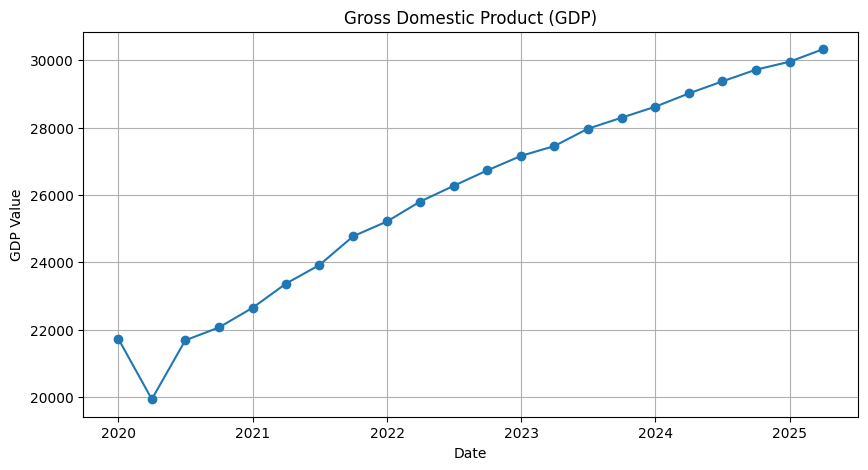

In [ ]:
from fredapi import Fred
import matplotlib.pyplot as plt

# Initialize Fred API client
fred = Fred(api_key=api_key)

# Example: Search for 'gross domestic product' and sort results in ascending order
gdp = fred.search('gross domestic product', sort_order='asc')

#see first 5 values
print(gdp.head(5))

# Example: get the series of GDP between our given timeframe
gdp_data = fred.get_series('GDP', observation_start=start_date, observation_end=end_date)

# Simple plot of the GDP data
plt.figure(figsize=(10, 5))
plt.plot(gdp_data.index, gdp_data.values, marker='o')
plt.title('Gross Domestic Product (GDP)')
plt.xlabel('Date')
plt.ylabel('GDP Value')
plt.grid()
plt.show()

Actual Data Pulls Happen here

In [ ]:
import pandas as pd
import numpy as np
from pandas_datareader import data as pdr

# ---------- SEP projection series (verified FRED IDs) ----------
# step 3 above, check codes in data below
SEP_SERIES = {
    "gdp": { #gdp projections, all not seasonally adjusted
        "median": "GDPC1MD", #only 3 years out
        "central_tendency_midpoint": "GDPC1CTM", #only 3 years out
        "range_midpoint": "GDPC1RM", #only 3 years out
        "longer_run_central_tendency_midpoint": "GDPC1CTMLR", #at this time includes projections from historical time
    },
    "unemployment": { #unemployment projections, all not seasonally adjusted
        "median": "UNRATEMD", #only 3 years out
        "central_tendency_midpoint": "UNRATECTM", #only 3 years out
        "range_midpoint": "UNRATERM", #only 3 years out
        "longer_run_central_tendency_midpoint": "UNRATECTMLR", #at this time includes projections from historical time
    },
    "fed_funds": { #fed funds interest rate projections, all not seasonally adjusted
        "median": "FEDTARMD", #only 3 years out
        "central_tendency_midpoint": "FEDTARCTM", #only 3 years out
        "range_midpoint": "FEDTARRM", #only 3 years out
        "longer_run_central_tendency_midpoint": "FEDTARCTMLR", #at this time includes projections from historical time
    },
    "pce": { #pce inflation projections, all not seasonally adjusted, no longer run CTM
        "median": "PCECTPIMD", #only 3 years out
        "central_tendency_midpoint": "PCECTPICTM", #only 3 years out
        "range_midpoint": "PCECTPIRM" #only 3 years out
    },
    "core_pce": { #core pce inflation projections, all not seasonally adjusted, no longer run CTM
        "median": "JCXFEMD", #only 3 years out
        "central_tendency_midpoint": "JCXFECTM", #only 3 years out
        "range_midpoint": "JCXFERM" #only 3 years out
    }
}

# ---------- Helper to fetch FRED series ----------
def fred(code: str, start_date: str, end_date: str) -> pd.Series:
    # Fetch data from FRED
    # Inputs: code (str) - FRED series code, start_date (str) - start date desired, end_date (str) - end date desired
    try:
        s = pdr.DataReader(code, "fred", start = start_date, end = end_date)[code] #select data during this period
        s.name = code
        return s
    except Exception as e:
        print(f"Warning: Could not fetch {code} ({e})")
        return pd.Series(dtype=float)

# ---------- Build SEP (wide & long) ----------
def pull_sep_wide() -> pd.DataFrame:
    frames = []
    for group, codes in SEP_SERIES.items():
        for label, code in codes.items():
            s = fred(code, start_date, end_date).to_frame()
            s.columns = [f"{group}.{label}.{code}"]
            frames.append(s)
    wide = pd.concat(frames, axis=1).sort_index()
    return wide

def sep_wide_to_long(wide: pd.DataFrame) -> pd.DataFrame:
    long = (
        wide.reset_index()
            .rename(columns={"DATE": "obs_date"})
            .melt(id_vars=["obs_date"], var_name="series", value_name="value")
            #.dropna(subset=["value"])
    )
    parts = long["series"].str.split(r"\.", n=2, expand=True)
    long["variable_group"] = parts[0]
    long["measure"] = parts[1]
    long["fred_code"] = parts[2]
    # SEP obs_date is annual (Jan 1 as year marker). Extract projection year.
    long["year"] = pd.to_datetime(long["obs_date"]).dt.year
    long["type"] = "projection"
    return long[["year","variable_group","measure","fred_code","type","value","obs_date"]]

#edits will be made here if you want to add on more macroeconomic data
def build_actuals() -> pd.DataFrame:
    """Build actuals for GDP, Unemployment, Fed Funds, PCE, Core PCE, and additional added on data."""

    # Helper function to finalize the DataFrame
    def finalize(series, variable_group, measure, fred_code, month_day=None):
        #inputs: series (series) - the data series to finalize, variable_group (str) - the variable group name, measure (str) - the measurment name, fred_code (str) - the FRED code from source
        # month_day (str) - optional month and day string to append to the year for obs_date, if None will default to the index in series
        df = series.to_frame("value")
        # normalize index to integer years
        if isinstance(df.index, pd.PeriodIndex):
            years = df.index.year
        elif isinstance(df.index, pd.DatetimeIndex):
            years = df.index.year
        else:
            years = df.index.astype(int)

        df.index = years
        df.index.name = "year"

        # construct obs_date safely
        if month_day is not None:
            df["obs_date"] = pd.to_datetime(df.index.map(str) + month_day)
        else:
            df["obs_date"] = pd.to_datetime(df.index.map(str))

        # metadata
        df["variable_group"] = variable_group
        df["measure"] = measure
        df["fred_code"] = fred_code
        df["type"] = "actual"
        df["source"] = "actuals"
        return df

    # --- Beginning of Actuals: You can make adjustments here and add additional data here ---

    # --- GDP: real GDP (GDPC1), Q4/Q4 % ---
    gdp = fred("GDPC1", start_date, end_date) #real gross domestic product, done as part of q4 ending percentage, seasonally adjusted
    gdp_q4 = gdp.resample("QE").last().to_period("Q") #pull Q4 data
    gdp_q4 = gdp_q4[gdp_q4.index.quarter == 4]
    gdp_q4q4 = (gdp_q4 / gdp_q4.shift(1) - 1) * 100 #make is percent
    gdp_q4q4.index = gdp_q4q4.index.year
    gdp_final = finalize(gdp_q4q4, "gdp", "actual_q4q4", "GDPC1", month_day='-12-31') #month_day input forces to end of month in this case

    # --- Unemployment: UNRATE, Q4 average ---
    u = fred("UNRATE", start_date, end_date) # unemployment rate at the end of q4 for a given year, raw data taken monthly, seasonally adjusted
    u_q = u.resample("QE").mean()
    u_q4 = u_q[u_q.index.quarter == 4]
    u_q4.index = u_q4.index.year
    u_final = finalize(u_q4, "unemployment", "actual_q4_avg", "UNRATE", month_day='-12-31')

    # --- Fed Funds: FEDFUNDS, year-end value ---
    f = fred("FEDFUNDS", start_date, end_date) #fed funds interest rate at year end, values taken at end of the day daily from raw data, not seasonally adjusted
    f_m = f.resample("ME").last()
    f_yend = f_m[f_m.index.month == 12]
    f_yend.index = f_yend.index.year
    f_final = finalize(f_yend, "fed_funds", "actual_yearend", "FEDFUNDS", month_day='-12-31')

    # --- PCE: PCECTPI, Q4/Q4 % ---
    pce = fred("PCECTPI", start_date, end_date) #PCE price index of inflation in chain type, done as part of q4 ending percentage, seasonally adjusted
    pce_q4 = pce.resample("QE").last().to_period("Q")
    pce_q4 = pce_q4[pce_q4.index.quarter == 4]
    pce_q4q4 = (pce_q4 / pce_q4.shift(1) - 1) * 100
    pce_q4q4.index = pce_q4q4.index.year
    pce_final = finalize(pce_q4q4, "pce", "actual_q4q4", "PCECTPI", month_day='-12-31')

    # --- Core PCE: PCEPILFE, Q4/Q4 % ---
    core = fred("PCEPILFE", start_date, end_date) #PCE price index less food and energy, done as part of q4 ending percentage, seasonally adjusted
    core_q4 = core.resample("QE").last().to_period("Q")
    core_q4 = core_q4[core_q4.index.quarter == 4]
    core_q4q4 = (core_q4 / core_q4.shift(1) - 1) * 100
    core_q4q4.index = core_q4q4.index.year
    core_final = finalize(core_q4q4, "core_pce", "actual_q4q4", "PCEPILFE", month_day='-12-31')

    # --- Additional Historical Data Additions that may be relevant Beyond SEP Data ---

    # --- Actuals: NBER recession indicator ---
    #see here on information on NBER recession indicators: https://www.nber.org/research/business-cycle-dating/business-cycle-dating-procedure-frequently-asked-questions
    rec = fred("USRECQ", start_date, end_date) #original data is calculated quarterly at end of the quarter with no seasonal adjustments, 1 if recession, 0 if not
    rec_q = rec.resample("QE").max() #pulling quarterly info
    rec_q.index.name = "obs_date"
    rec_q = rec_q.to_frame("value")
    rec_q["variable_group"] = "recession"
    rec_q["measure"] = "nber_recession"
    rec_q["fred_code"] = "USRECQ"
    rec_q["type"] = "actual"
    rec_q["source"] = "actuals"
    rec_final = rec_q.reset_index()

    # --- Actuals: Sticky Price Consumer Price Index (CPI) ---
    cpi = fred("STICKCPIM157SFRBATL", start_date, end_date) #original data is calculated monthly at end of the month while also accounting for seasonal adjustments, percent change
    cpi_q = cpi.resample("QE").last() #gets at the end of quarter
    cpi_q.index.name = "obs_date"
    cpi_q = cpi_q.to_frame("value")
    cpi_q["variable_group"] = "inflation_sticky"
    cpi_q["measure"] = "sticky_price_cpi"
    cpi_q["fred_code"] = "STICKCPIM157SFRBATL"
    cpi_q["type"] = "actual"
    cpi_q["source"] = "actuals"
    cpi_final = cpi_q.reset_index()

    # --- Actuals: Median Consumer Price Index (CPI) ---
    cpi_median = fred("MEDCPIM158SFRBCLE", start_date, end_date) #original data is calculated monthly at end of the month while also accounting for seasonal adjustments, annual percent change
    cpi_median_q = cpi_median.resample("QE").last() #gets at the end of quarter
    cpi_median_q.index.name = "obs_date"
    cpi_median_q = cpi_median_q.to_frame("value")
    cpi_median_q["variable_group"] = "inflation_median"
    cpi_median_q["measure"] = "median_price_cpi"
    cpi_median_q["fred_code"] = "MEDCPIM158SFRBCLE"
    cpi_median_q["type"] = "actual"
    cpi_median_q["source"] = "actuals"
    cpi_median_final = cpi_median_q.reset_index()

    # --- Actuals: Auto Diesel Fuel Costs in US Urban Metros (PPG) ---
    auto_diesel = fred("APU000074717", start_date, end_date) #original data is calculated monthly at end of the month with no seasonal adjustments, us dollars per gallon
    auto_diesel_q = auto_diesel.resample("QE").last() #gets at the end of quarter
    auto_diesel_q.index.name = "obs_date"
    auto_diesel_q = auto_diesel_q.to_frame("value")
    auto_diesel_q["variable_group"] = "fuel_price"
    auto_diesel_q["measure"] = "auto_diesel_price"
    auto_diesel_q["fred_code"] = "APU000074717"
    auto_diesel_q["type"] = "actual"
    auto_diesel_q["source"] = "actuals"
    auto_diesel_final = auto_diesel_q.reset_index()

    # --- Actuals: Consumer Price Index for Fuel Oil and Other Fuels in US Urban Metros (indexed from 1982-1984=100) ---
    fuel_oil = fred("CUSR0000SEHE", start_date, end_date) #original data is calculated monthly at end of the month while also accounting for seasonal adjustments, index at 100 for average in 1982-1984
    fuel_oil_q = fuel_oil.resample("QE").last() #gets at the end of quarter
    fuel_oil_q.index.name = "obs_date"
    fuel_oil_q = fuel_oil_q.to_frame("value")
    fuel_oil_q["variable_group"] = "inflation_fuel"
    fuel_oil_q["measure"] = "fuel_oil_cpi"
    fuel_oil_q["fred_code"] = "CUSR0000SEHE"
    fuel_oil_q["type"] = "actual"
    fuel_oil_q["source"] = "actuals"
    fuel_oil_final = fuel_oil_q.reset_index()

    # --- Look Aheads: X-Month Macroeconomic Uncertainty ---
    #these next 3 values may assist in trustability in our other macroeconomic projections
    #see: http://dx.doi.org/10.1257/aer.20131193 for reference on this info (Jurado, ludvigson, Ng (2015) Measuring Uncertainty)
    #3 month
    look_ahead3m = fred("JLNUM3M", start_date, end_date) #original data is calculated monthly at end of the month while scaled from a 3 month look ahead
    look_ahead3m_q = look_ahead3m.resample("QE").last() #gets at the end of quarter
    look_ahead3m_q.index.name = "obs_date"
    look_ahead3m_q = look_ahead3m_q.to_frame("value")
    look_ahead3m_q["variable_group"] = "macroeconomic_uncertainty"
    look_ahead3m_q["measure"] = "3_month_look_ahead"
    look_ahead3m_q["fred_code"] = "JLNUM3M"
    look_ahead3m_q["type"] = "actual"
    look_ahead3m_q["source"] = "actuals"
    look_ahead_final_3m = look_ahead3m_q.reset_index()

    #1 month
    look_ahead1m = fred("JLNUM1M", start_date, end_date) #original data is calculated monthly at end of the month while scaled from a 1 month look ahead
    look_ahead1m_q = look_ahead1m.resample("QE").last() #gets at the end of quarter
    look_ahead1m_q.index.name = "obs_date"
    look_ahead1m_q = look_ahead1m_q.to_frame("value")
    look_ahead1m_q["variable_group"] = "macroeconomic_uncertainty"
    look_ahead1m_q["measure"] = "1_month_look_ahead"
    look_ahead1m_q["fred_code"] = "JLNUM1M"
    look_ahead1m_q["type"] = "actual"
    look_ahead1m_q["source"] = "actuals"
    look_ahead_final_1m = look_ahead1m_q.reset_index()

    #1 year
    look_ahead1y = fred("JLNUM12M", start_date, end_date) #original data is calculated monthly at end of the month while scaled from a 12 month look ahead
    look_ahead1y_q = look_ahead1y.resample("QE").last() #gets at the end of quarter
    look_ahead1y_q.index.name = "obs_date"
    look_ahead1y_q = look_ahead1y_q.to_frame("value")
    look_ahead1y_q["variable_group"] = "macroeconomic_uncertainty"
    look_ahead1y_q["measure"] = "1_year_look_ahead"
    look_ahead1y_q["fred_code"] = "JLNUM12M"
    look_ahead1y_q["type"] = "actual"
    look_ahead1y_q["source"] = "actuals"
    look_ahead_final_1y = look_ahead1y_q.reset_index()

    # Combine all data for final output
    actuals = pd.concat([gdp_final, u_final, f_final, pce_final, core_final, rec_final, cpi_final, cpi_median_final, auto_diesel_final, fuel_oil_final, look_ahead_final_3m, look_ahead_final_1m, look_ahead_final_1y])
    actuals.index.name = "year"
    actuals.reset_index(inplace=True)

    return actuals



# ---------- Merge projections + actuals ----------
def build_combined() -> pd.DataFrame:
    sep_wide = pull_sep_wide()
    sep_long = sep_wide_to_long(sep_wide)
    actuals = build_actuals()
    combined = pd.concat([sep_long, actuals], ignore_index=True)
    combined = combined.sort_values(["variable_group","year","type","measure"]).reset_index(drop=True)
    combined["value"] = combined["value"].fillna(np.nan)  # or leave as NaN
    return combined, sep_wide

if __name__ == "__main__":
    combined, sep_wide = build_combined()
    combined.to_csv("sep_with_actuals_tidy.csv", index=False)
    sep_wide.to_csv("sep_only_wide.csv", index=True)
    print("Wrote:")
    print("  - sep_with_actuals_tidy.csv  (projections + actuals, tidy/long)")
    print("  - sep_only_wide.csv          (SEP projections only, wide)")
    print("\nPreview:")
    print(combined.head(20).to_string(index=False))


Wrote:
  - sep_with_actuals_tidy.csv  (projections + actuals, tidy/long)
  - sep_only_wide.csv          (SEP projections only, wide)

Preview:
 year variable_group                   measure fred_code       type    value   obs_date  source
 2020       core_pce               actual_q4q4  PCEPILFE     actual      NaN 2020-12-31 actuals
 2020       core_pce central_tendency_midpoint  JCXFECTM projection      NaN 2020-06-10     NaN
 2020       core_pce central_tendency_midpoint  JCXFECTM projection      NaN 2020-09-16     NaN
 2020       core_pce central_tendency_midpoint  JCXFECTM projection      NaN 2020-12-16     NaN
 2020       core_pce                    median   JCXFEMD projection      NaN 2020-06-10     NaN
 2020       core_pce                    median   JCXFEMD projection      NaN 2020-09-16     NaN
 2020       core_pce                    median   JCXFEMD projection      NaN 2020-12-16     NaN
 2020       core_pce            range_midpoint   JCXFERM projection      NaN 2020-06-10  

Plotting Data with Matplotlib

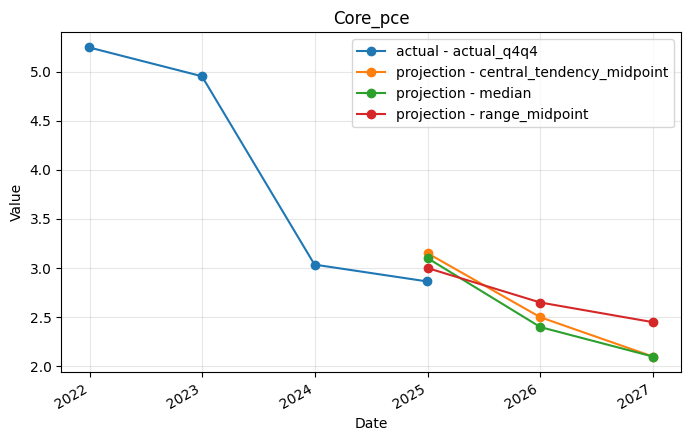

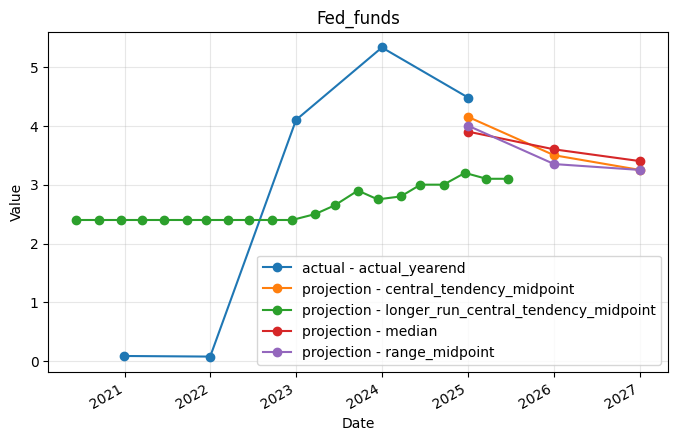

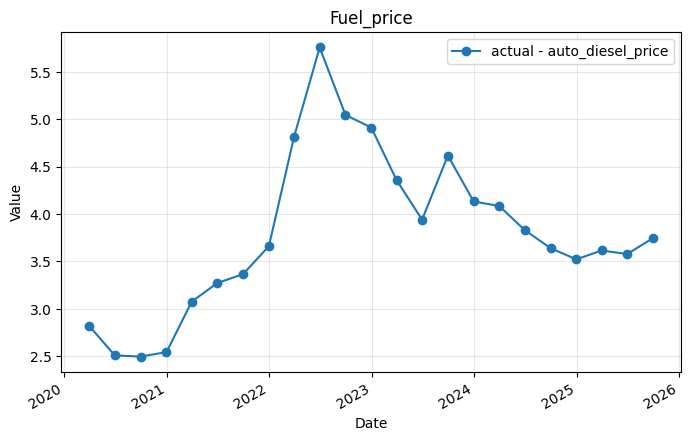

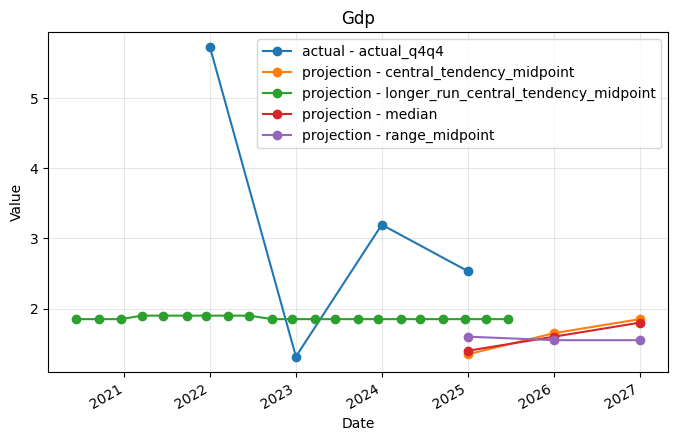

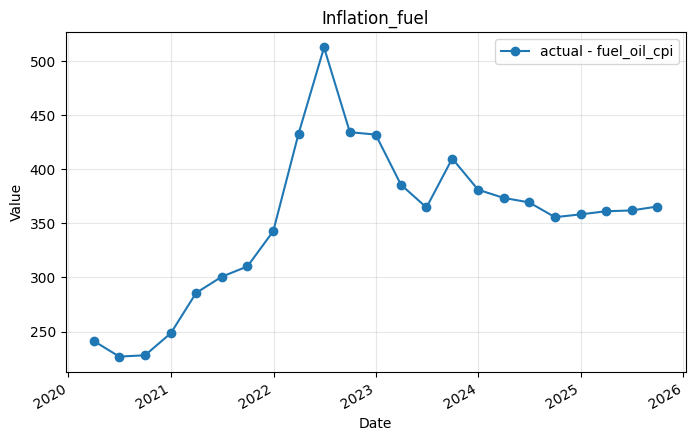

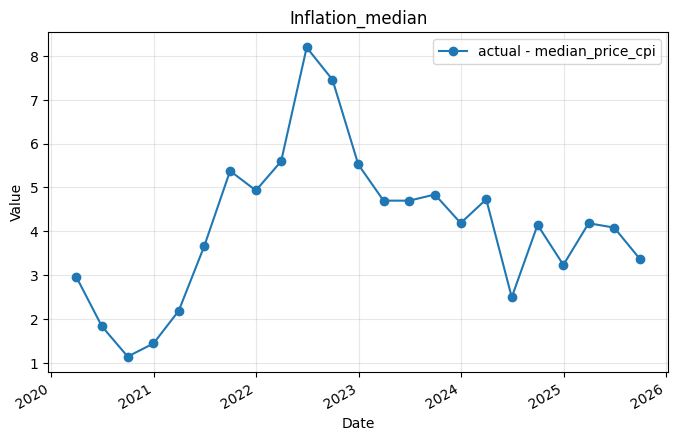

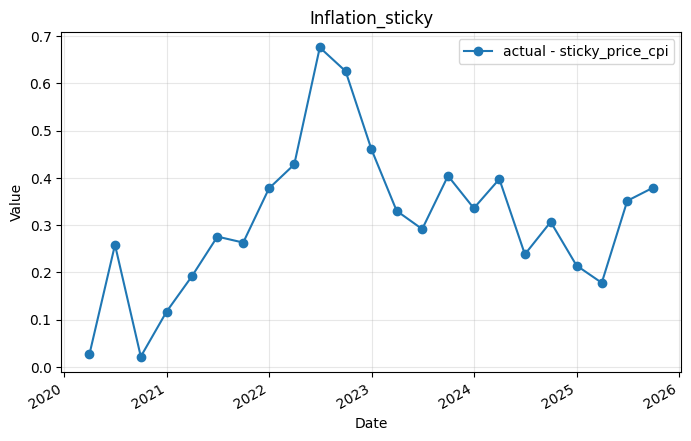

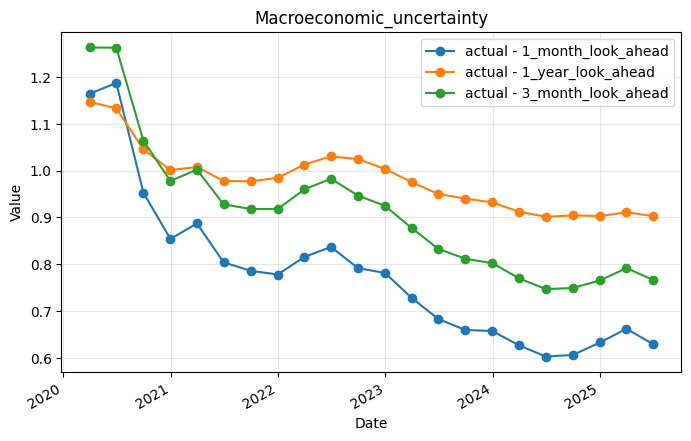

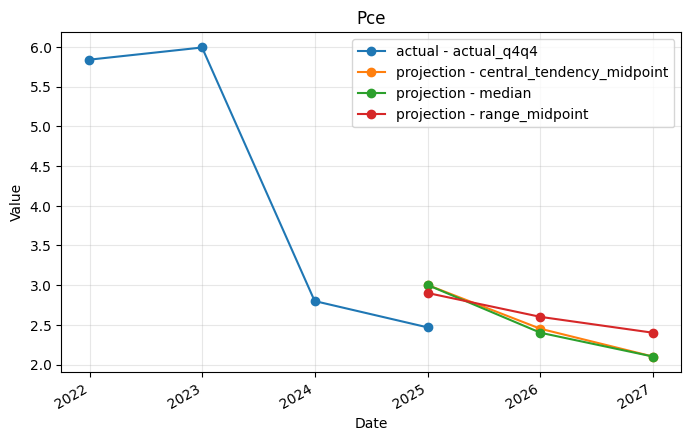

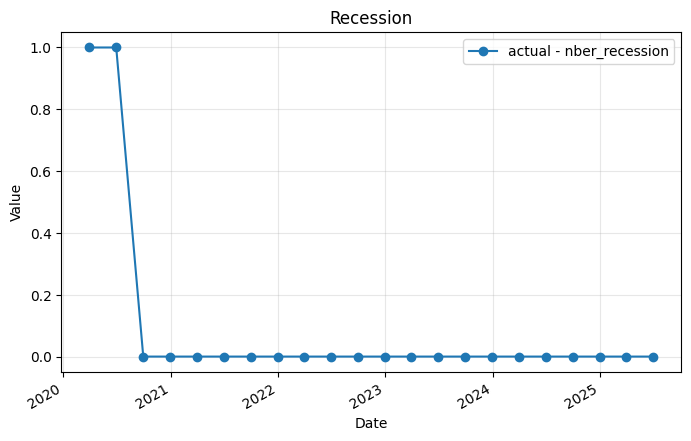

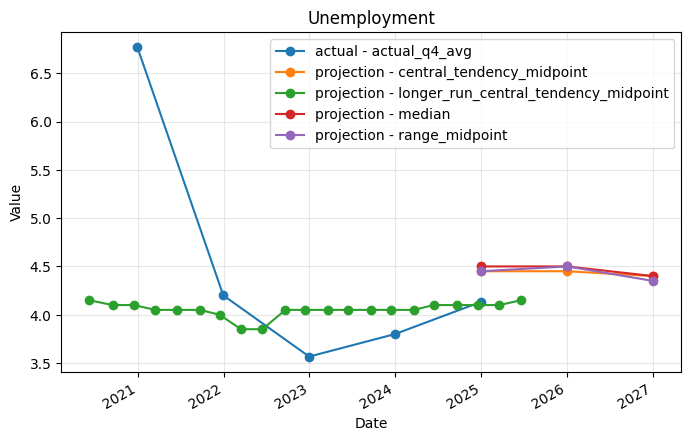

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

#loops through each variable group or series
for vg in combined["variable_group"].unique():

    df_vg = combined[combined["variable_group"] == vg]

    fig, ax = plt.subplots(figsize=(8, 5))

    for (type_, measure), df_sub in df_vg.groupby(["type", "measure"]):
        #loops through projections and acutals and measurement types for a specific variable group/series
        x = pd.to_datetime(df_sub["obs_date"])
        # build a clean dataframe with datetime + value
        df_plot = pd.DataFrame({"x": x, "y": df_sub["value"]}).dropna()
        df_plot = df_plot.sort_values("x")  # ensure chronological order

        # only plot if there are valid points
        if not df_plot.empty:
            ax.plot(
                df_plot["x"],
                df_plot["y"],
                marker="o",
                label=f"{type_} - {measure}"
            )

    ax.set_title(f"{vg.capitalize()}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.autofmt_xdate()
    plt.show()
